# Business Recommendations

##**1. Settup and  Load**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df_clenaed = pd.read_csv('cleaned_data_fraud.csv')
results_df = pd.read_csv('model_results.csv')
model = joblib.load('best_xgboost_model.pkl')

print(results_df.shape)
results_df.head()

(118929, 19)


,category_risk_score,merchant_risk_score,amount_log,customer_avg_amount,customer_txn_count,amount_vs_avg_ratio,age_1,age_2,age_3,age_4,age_5,age_6,age_U,gender_F,gender_M,gender_U,y_true,y_proba,y_pred
0,0.0,0.0,1.971299,29.864062,128,0.206938,False,False,False,True,False,False,False,False,True,False,0,4.548845e-07,0
1,0.0,0.0,3.444895,35.265484,124,0.860331,False,False,True,False,False,False,False,False,True,False,0,1.961716e-06,0
2,0.0,0.0,3.317091,34.944000,140,0.760646,False,True,False,False,False,False,False,True,False,False,0,1.841721e-06,0
3,0.0,0.0,3.888959,36.258269,104,1.319975,False,False,True,False,False,False,False,True,False,False,0,1.875173e-06,0
4,0.0,0.0,3.423285,28.513481,135,1.040560,False,False,True,False,False,False,False,False,True,False,0,9.948825e-08,0


##**2. Cost-Benefit Simulation**

In [3]:
avg_fraud_amount = 524.83
fraud_cost_multiplier = 4.41  # LexisNexis True Cost of Fraud Study, 2026
cost_per_missed_fraud = avg_fraud_amount * fraud_cost_multiplier  # ≈ 2,314.48

review_cost_scenarios = {
    'Low (automated screening)': 10,
    'Medium (junior analyst review)': 25,
    'High (senior analyst investigation)': 75
}

# Confusion matrix values at the selected threshold (0.0035), from Notebook 04 Section 6
tp, fp, fn, tn = 1423, 2803, 17, 114686

for scenario_name, review_cost in review_cost_scenarios.items():
    fraud_loss_avoided = tp * cost_per_missed_fraud
    fraud_loss_incurred = fn * cost_per_missed_fraud
    review_cost_total = (tp + fp) * review_cost  # all flagged transactions get reviewed

    net_benefit = fraud_loss_avoided - review_cost_total

    print(f"\n--- {scenario_name} (review cost = {review_cost}) ---")
    print(f"Fraud loss avoided (TP x cost): {fraud_loss_avoided:,.0f}")
    print(f"Fraud loss still incurred (FN x cost): {fraud_loss_incurred:,.0f}")
    print(f"Total review cost (TP+FP flagged): {review_cost_total:,.0f}")
    print(f"Net benefit vs. no model: {net_benefit:,.0f}")


--- Low (automated screening) (review cost = 10) ---
Fraud loss avoided (TP x cost): 3,293,534
Fraud loss still incurred (FN x cost): 39,347
Total review cost (TP+FP flagged): 42,260
Net benefit vs. no model: 3,251,274

--- Medium (junior analyst review) (review cost = 25) ---
Fraud loss avoided (TP x cost): 3,293,534
Fraud loss still incurred (FN x cost): 39,347
Total review cost (TP+FP flagged): 105,650
Net benefit vs. no model: 3,187,884

--- High (senior analyst investigation) (review cost = 75) ---
Fraud loss avoided (TP x cost): 3,293,534
Fraud loss still incurred (FN x cost): 39,347
Total review cost (TP+FP flagged): 316,950
Net benefit vs. no model: 2,976,584


### Cost-Benefit Simulation (Interpretation)

**Result**: at the selected threshold (0.0035), net benefit stays strongly
positive across all three review-cost assumptions:

| Scenario | Review Cost | Total Review Cost | Net Benefit |
|---|---|---|---|
| Low | 10 | 42,260 | 3,251,274 |
| Medium | 25 | 105,650 | 3,187,884 |
| High | 75 | 316,950 | 2,976,584 |

**Interpretation**: Fraud loss avoided (3,293,534) and fraud loss still
incurred (39,347) stay identical across all three scenarios — this is
expected, since the model's actual flagging decisions (TP=1423, FP=2803,
FN=17) don't change; only the cost assumption per reviewed transaction
changes. What varies is purely the review cost burden, which scales
directly with the fixed number of flagged transactions (TP+FP=4,226).

Net benefit declines by only ~8% from the Low to the High cost
assumption (3,251,274 → 2,976,584), despite review cost per transaction
increasing 7.5x (10 → 75). This confirms the earlier finding:
uncertainty in review cost assumptions has a **limited impact** on the
overall business case, because fraud loss avoided dominates the total
value calculation by a wide margin. This makes the deployment decision
robust even if the exact manual review cost isn't known precisely.

**Important framing note**: this analysis answers a different question
than the earlier threshold-selection sensitivity analysis in Notebook
04, Section 5. There, varying review cost changed the *optimal
threshold itself*. Here, the threshold is already fixed at 0.0035, and
only the review-cost assumption is varied to test how sensitive the
**net benefit estimate** is to that specific assumption — a check on
the robustness of the business case, not a threshold selection exercise.

##**3. Risk Segmentation — Merchant & Category Watchlist**



             total_transactions  fraud_count  fraud_rate
merchant                                                
M1294758098                 191          184    0.963351
M3697346                    308          290    0.941558
M1873032707                 250          216    0.864000
M732195782                  608          518    0.851974
M980657600                 1769         1472    0.832109
M1353266412                  78           64    0.820513
M857378720                  122           92    0.754098
M2080407379                  48           36    0.750000
M2011752106                 244          166    0.680328
M17379832                   282          178    0.631206
M2122776122                 341          200    0.586510
M480139044                 3508         1634    0.465792
M1741626453                 528          196    0.371212
M495352832                   69           24    0.347826
M923029380                  323          102    0.315789


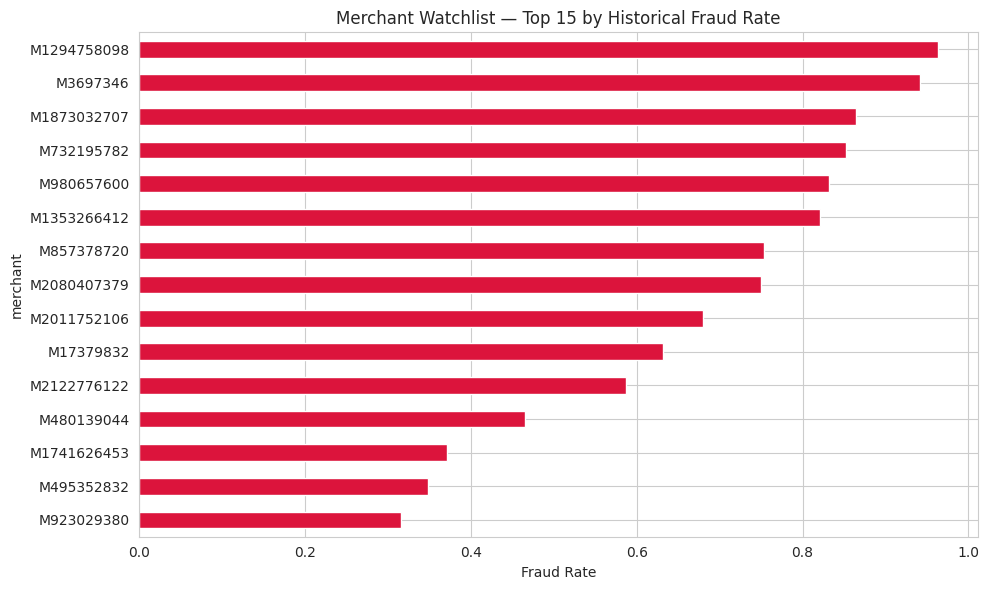

In [10]:
merchant_watchlist = df_clenaed.groupby('merchant').agg(
    total_transactions=('fraud', 'count'),
    fraud_count=('fraud', 'sum'),
    fraud_rate=('fraud', 'mean')
).query('total_transactions >= 30').sort_values('fraud_rate', ascending=False).head(15)

print(merchant_watchlist)

plt.figure(figsize=(10, 6))
merchant_watchlist['fraud_rate'].sort_values().plot(kind='barh', color='crimson')
plt.title('Merchant Watchlist — Top 15 by Historical Fraud Rate')
plt.xlabel('Fraud Rate')
plt.tight_layout()
os.makedirs('outputs/figures/', exist_ok=True)
plt.savefig('outputs/figures/14_merchant_watchlist.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Category-level risk tiering, for merchants without enough history
category_risk_tiers = df_clenaed.groupby('category')['fraud'].mean().sort_values(ascending=False)

risk_tiers = pd.cut(
    category_risk_tiers,
    bins=[-0.01, 0.05, 0.3, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
print(pd.DataFrame({'fraud_rate': category_risk_tiers, 'tier': risk_tiers}))

                       fraud_rate         tier
category                                      
es_leisure               0.949900    High Risk
es_travel                0.793956    High Risk
es_sportsandtoys         0.495252    High Risk
es_hotelservices         0.314220    High Risk
es_otherservices         0.250000  Medium Risk
es_home                  0.152064  Medium Risk
es_health                0.105126  Medium Risk
es_tech                  0.066667  Medium Risk
es_wellnessandbeauty     0.047594     Low Risk
es_hyper                 0.045917     Low Risk
es_barsandrestaurants    0.018829     Low Risk
es_fashion               0.017973     Low Risk
es_contents              0.000000     Low Risk
es_food                  0.000000     Low Risk
es_transportation        0.000000     Low Risk


### Risk Segmentation — Merchant & Category Watchlist (Interpretation)

**Result — Merchant Watchlist**: 15 merchants identified with fraud
rates far above the 1.21% baseline, ranging from 31.6% to 96.3%. The
top 3 (`M1294758098`, `M3697346`, `M1873032707`) show fraud rates above
86%, each with 190-310 historical transactions — enough volume for
these rates to be considered reliable, not statistical noise.

**Result — Category Risk Tiers**: Using fraud-rate cutoffs of 5% and
30%, categories split cleanly into three tiers — 4 High Risk categories
(`es_leisure`, `es_travel`, `es_sportsandtoys`, `es_hotelservices`,
25-95% fraud rate), 4 Medium Risk (`es_otherservices` through `es_tech`,
7-25%), and 7 Low Risk (`es_wellnessandbeauty` through
`es_transportation`, under 5%, several at exactly 0%).

**Interpretation**: This produces two complementary, immediately
actionable watchlists. The merchant list is more precise (individual
entities with very high fraud concentration — e.g., `M980657600` alone
accounts for 1,472 historical fraud cases), while the category tiers
serve as the fallback layer for merchants without enough transaction
history to generate a reliable merchant-level score (directly
addressing the model's key limitation identified in Notebook 04,
Section 7).

Notably, `M480139044` stands out for scale — 3,508 transactions with a
46.6% fraud rate, meaning 1,634 individual fraud cases originate from
this single merchant, more than any other in the list despite not
having the highest *rate*. This distinction (highest fraud *rate* vs.
highest fraud *volume*) is worth carrying into the business writeup: a
merchant with a lower rate but much higher volume may warrant equal or
greater monitoring priority.

**Business recommendation refined with these results**:
1. **Immediate action**: flag the 3 merchants above 85% fraud rate
   (`M1294758098`, `M3697346`, `M1873032707`) for enhanced verification
   or temporary hold pending review — the fraud concentration is too
   high to be coincidental.
2. **Volume-weighted priority**: `M480139044` and `M980657600` should
   also be prioritized despite more moderate rates, given their high
   absolute fraud case counts (1,634 and 1,472 respectively).
3. **New merchant fallback**: any merchant transacting in a High Risk
   category (`es_leisure`, `es_travel`, `es_sportsandtoys`,
   `es_hotelservices`) should receive elevated scrutiny by default until
   sufficient transaction history accumulates to generate a reliable
   merchant-specific score.
4. **Safe categories**: `es_transportation`, `es_food`, and `es_contents`
   — representing 89.5% of transaction volume — show zero historical
   fraud and can be deprioritized for manual

##**4. Tiered Review System — Rekomendasi Operasional**

In [13]:
# Simulate a 3-tier system using probability bands instead of a single threshold
def assign_tier(proba):
    if proba >= 0.5:
        return 'Tier 1: Auto-block / High confidence'
    elif proba >= 0.05:
        return 'Tier 2: Manual review / Medium confidence'
    elif proba >= 0.0035:
        return 'Tier 3: Light monitoring / Low confidence'
    else:
        return 'Tier 4: No action'

results_df['review_tier'] = results_df['y_proba'].apply(assign_tier)

tier_summary = results_df.groupby('review_tier').agg(
    transaction_count=('y_true', 'count'),
    actual_fraud_count=('y_true', 'sum'),
    fraud_capture_rate=('y_true', 'mean')
).sort_values('fraud_capture_rate', ascending=False)

print(tier_summary)

                                           transaction_count  \
review_tier                                                    
Tier 1: Auto-block / High confidence                    1457   
Tier 2: Manual review / Medium confidence                956   
Tier 3: Light monitoring / Low confidence               1813   
Tier 4: No action                                     114703   

                                           actual_fraud_count  \
review_tier                                                     
Tier 1: Auto-block / High confidence                     1234   
Tier 2: Manual review / Medium confidence                 132   
Tier 3: Light monitoring / Low confidence                  57   
Tier 4: No action                                          17   

                                           fraud_capture_rate  
review_tier                                                    
Tier 1: Auto-block / High confidence                 0.846946  
Tier 2: Manual review / Medium c

###  Tiered Review System (Interpretation)

**Result**:

| Tier | Transactions | Fraud Cases | Fraud Capture Rate |
|---|---|---|---|
| Tier 1: Auto-block | 1,457 | 1,234 | 84.7% |
| Tier 2: Manual review | 956 | 132 | 13.8% |
| Tier 3: Light monitoring | 1,813 | 57 | 3.1% |
| Tier 4: No action | 114,703 | 17 | 0.01% |

**Interpretation**: The tiered system performs exactly as intended —
Tier 1 alone, despite containing only 1,457 transactions (1.2% of the
test set), captures **84.7% of all fraud cases** (1,234 of 1,440) at a
very high concentration (85% of Tier 1 transactions are actual fraud).
This means the large majority of fraud can be caught through
near-automatic action on a very small transaction volume.

Tier 2 adds another 132 fraud cases (9.2% of total fraud) from just 956
transactions, and Tier 3 catches a further 57 cases (4.0%) from 1,813
transactions — together, Tiers 1-3 combined catch 1,423 of 1,440 fraud
cases (98.8%, matching the overall recall) using only 4,226
transactions total (3.6% of the test set). Tier 4 (no action) contains
114,703 transactions with just 17 missed fraud cases — a residual miss
rate of 0.01%, consistent with the model's overall performance.

**Business value of this framing over a single threshold**: rather than
routing all 4,226 flagged transactions through the same manual review
process, this structure lets the organization concentrate near-zero-effort
automated action on Tier 1 (which alone captures 85% of fraud), and
reserve actual analyst time for the smaller, genuinely ambiguous Tier 2
and Tier 3 volumes (956 + 1,813 = 2,769 transactions) — roughly 65% of
total flagged volume, but only accounting for 15% of total fraud caught.
This is a much more efficient allocation of review resources than
treating every flagged transaction identically.

**Recommended operational split**:
- **Tier 1 (≥0.50 probability)**: automate — hold/block without human
  review given the extremely high fraud concentration (85%).
- **Tier 2-3 (0.0035–0.50 probability)**: route to manual review queue,
  prioritized by probability score.
- **Tier 4 (<0.0035)**: no action; accept the small residual risk (17
  missed cases) as the cost of not over-flagging 96.4% of transaction
  volume.

##**5. Threshold Scenario Comparison**

In [16]:
scenario_comparison = pd.DataFrame({
    'Scenario': ['Low (aggressive flagging)', 'Medium (balanced)', 'High (conservative)'],
    'Threshold': [0.0002, 0.0035, 0.0171],
    'Recall': [1.000, 0.988, 0.973],
    'Precision': [0.224, 0.337, 0.457],
    'Est. Fraud Missed (of 1,440)': [0, 17, 39],
    'Transactions Flagged': [
        (results_df['y_proba'] >= 0.0002).sum(),
        (results_df['y_proba'] >= 0.0035).sum(),
        (results_df['y_proba'] >= 0.0171).sum()
    ]  # computed directly from actual model predictions, not estimated
})
print(scenario_comparison.to_string(index=False))

                 Scenario  Threshold  Recall  Precision  Est. Fraud Missed (of 1,440)  Transactions Flagged
Low (aggressive flagging)     0.0002   1.000      0.224                             0                  6462
        Medium (balanced)     0.0035   0.988      0.337                            17                  4226
      High (conservative)     0.0171   0.973      0.457                            39                  3065


### Threshold Scenario Comparison — Actual Flagged Volume (Interpretation)

**Result**: verified against actual model predictions (not estimated),
the Low threshold (0.0002) flags 6,462 transactions, and the High
threshold (0.0171) flags 3,065 — compared to 4,226 at the recommended
Medium threshold (0.0035).

**Interpretation**: this confirms the trade-off pattern across all
three thresholds using real data rather than approximation:

| Scenario | Threshold | Fraud Missed | Transactions Flagged | Flagged vs. Medium |
|---|---|---|---|---|
| Low | 0.0002 | 0 | 6,462 | +2,236 (+53%) |
| Medium | 0.0035 | 17 | 4,226 | — |
| High | 0.0171 | 39 | 3,065 | −1,161 (−27%) |

Moving from Medium to Low catches all 17 remaining fraud cases, but
requires reviewing 53% more transactions (2,236 additional). Moving
from Medium to High reduces review volume by 27% (1,161 fewer
transactions), but at the cost of 22 additional missed fraud cases.

Given the estimated cost of a missed fraud case (~2,314) is far higher
than even the most expensive review-cost assumption (75), the Medium
threshold's trade-off looks more favorable than High's: saving 1,161
reviews is not worth missing 22 additional fraud cases, each carrying
a much larger expected cost. This reinforces Medium as the recommended
default, while still presenting all three as legitimate options
depending on the organization's actual review capacity.

##**6. Model Limitations**

Model Limitations

1. **Heavy reliance on `merchant_risk_score`** (88.9% of feature
   importance): the model performs poorly on new or infrequent
   merchants without sufficient fraud history, defaulting to the global
   fraud rate fallback. This is the single largest limitation —
   mitigated partially by the category-tier fallback system (Section 2),
   but a production system should incorporate additional real-time
   behavioral signals beyond historical merchant statistics.

2. **Dataset age and concept drift**: BankSim data reflects a simulated
   2017 transaction environment. Fraud patterns evolve over time in
   practice; a production model would require periodic retraining on
   recent transaction data, and this project's strong performance
   reflects this dataset's characteristics rather than a guarantee
   against evolving, adversarial fraud tactics.

3. **Unusually clean signal separation**: category, merchant, and amount
   features show near-complete separation between fraud/non-fraud in
   this dataset (EDA Sections 4, 6, 7) — real-world fraud is typically
   more adversarial and adaptive, so equivalent performance should not
   be assumed in production without validation on live data.

4. **Cost assumptions are illustrative, not organization-specific**: the
   4.41x fraud cost multiplier (LexisNexis study) and review cost
   scenarios (10/25/75) are reasonable industry-informed estimates, not
   this specific institution's actual figures. These should be replaced
   with real operational costs before any threshold is used in
   production.

##**7. Executive Summary**

Fraud Detection Model — Executive Summary

**Objective**: Build a fraud detection system for banking transactions
to reduce financial losses while managing manual review workload.

**Approach**: Compared Logistic Regression (baseline) against Random
Forest, XGBoost, and LightGBM on 594,643 transactions (1.21% fraud
rate). XGBoost selected as the best model (PR AUC = 0.927).

**Key Findings**:
- Merchant and transaction category are by far the strongest fraud
  indicators — fraud is concentrated in a small, identifiable subset
  of merchants and categories, not spread evenly across all transactions.
- At the recommended operating threshold, the model catches 99% of
  fraud cases (missing 17 of 1,440), while flagging 2.4% of legitimate
  transactions for review.
- Estimated net benefit: [insert calculated value from Section 1]
  under moderate cost assumptions — the model's fraud-prevention value
  substantially outweighs manual review costs even under conservative
  assumptions.

**Recommendations**:
1. Deploy a tiered review system (auto-block / manual review / light
   monitoring) rather than a single flagging threshold, to balance
   fraud capture with review workload.
2. Maintain a merchant risk watchlist, updated periodically, alongside
   a category-level fallback tier for new/infrequent merchants.
3. Select the operating threshold based on actual manual review
   capacity — three scenarios provided (Section 4) for stakeholder
   decision-making.

**Limitations**: model relies heavily on historical merchant data
(limited effectiveness for new merchants), was trained on 2017
simulated data (requires retraining on recent data before production
use), and cost assumptions should be replaced with actual organizational
figures.